<a href="https://colab.research.google.com/github/Aham0803/PySpark/blob/main/Pyspark_basics_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

pyspark is the python api for apache spark , an open source big data processing framework . it provides powerful and scalable platform for data processing and analystics. The notebook will cover the basics of Pyspark and guide you thhrough some fundamental concepts and operation

In [2]:
!pip install pyspark

Before we start using PySpark, we need to import the necessary libraries.

In [3]:
import pyspark
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np


3. Initializing SparkSession -
To interact with Spark, we need to create a SparkSession, which serves as the entry point for using PySpark.

In [4]:
spark = SparkSession.builder.appName("PySpark Basics").getOrCreate()


4. Loading Data -> PySpark supports various data formats, including CSV, JSON, Parquet, and more. Let's see how to load a CSV file into a PySpark DataFrame.

header -> It tells PySpark that the first row of the CSV file contains column names, not actual data.

inferSchema -> It tells PySpark to look at the values in each column and automatically determine their data types.

In [5]:
# Read a CSV File
data = spark.read.csv("/content/Stores.csv" , header = True , inferSchema= True)

5. Exploring Data ->
once the data is loaded into pyspark dataframe , we can perform various operations to explore data

In [7]:
#Display the first few rows of dataframe
data.show()

+---------+----------+---------------+--------------------+-----------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|
+---------+----------+---------------+--------------------+-----------+
|        1|      1659|           1961|                 530|      66490|
|        2|      1461|           1752|                 210|      39820|
|        3|      1340|           1609|                 720|      54010|
|        4|      1451|           1748|                 620|      53730|
|        5|      1770|           2111|                 450|      46620|
|        6|      1442|           1733|                 760|      45260|
|        7|      1542|           1858|                1030|      72240|
|        8|      1261|           1507|                1020|      37720|
|        9|      1090|           1321|                 680|      46310|
|       10|      1030|           1235|                1130|      44150|
|       11|      1187|           1439|                1090|     

In [8]:
# Display the schema of the DataFrame
data.printSchema()

root
 |-- Store ID : integer (nullable = true)
 |-- Store_Area: integer (nullable = true)
 |-- Items_Available: integer (nullable = true)
 |-- Daily_Customer_Count: integer (nullable = true)
 |-- Store_Sales: integer (nullable = true)



### Row Counts

In [9]:
# get the number of rows in the dataframe
data.count()

896

In [10]:
# get summary statistics of numerical columns
data.describe().show()

+-------+----------------+------------------+------------------+--------------------+------------------+
|summary|       Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|
+-------+----------------+------------------+------------------+--------------------+------------------+
|  count|             896|               896|               896|                 896|               896|
|   mean|           448.5|1485.4095982142858|1782.0357142857142|   786.3504464285714| 59351.30580357143|
| stddev|258.797217913949|250.23701095319237| 299.8720525241988|  265.38928076727075|17190.741894878298|
|    min|               1|               775|               932|                  10|             14920|
|    max|             896|              2229|              2667|                1560|            116320|
+-------+----------------+------------------+------------------+--------------------+------------------+



## 6. Data Transformation

pyspark provides a wide range of transformation operations to manipulate and preprocesses data. Here are a few examples

In [13]:
#select specific column
selected_data = data.select("Store ID " ,"Store_Sales")

In [14]:
selected_data.show()

+---------+-----------+
|Store ID |Store_Sales|
+---------+-----------+
|        1|      66490|
|        2|      39820|
|        3|      54010|
|        4|      53730|
|        5|      46620|
|        6|      45260|
|        7|      72240|
|        8|      37720|
|        9|      46310|
|       10|      44150|
|       11|      71280|
|       12|      57620|
|       13|      60470|
|       14|      59130|
|       15|      66360|
|       16|      78870|
|       17|      77250|
|       18|      38170|
|       19|      63540|
|       20|      40190|
+---------+-----------+
only showing top 20 rows


In [15]:
# filter rows based on condition
filtered_data = data.filter(data["Daily_Customer_Count"] < 100)

In [16]:
filtered_data.show()

+---------+----------+---------------+--------------------+-----------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|
+---------+----------+---------------+--------------------+-----------+
|       40|      1270|           1516|                  10|      45480|
|      152|      1662|           1986|                  70|      63730|
+---------+----------+---------------+--------------------+-----------+



In [17]:
filtered_data = data.filter(data["Daily_Customer_Count"] < 500)

In [18]:
filtered_data.show()

+---------+----------+---------------+--------------------+-----------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|
+---------+----------+---------------+--------------------+-----------+
|        2|      1461|           1752|                 210|      39820|
|        5|      1770|           2111|                 450|      46620|
|       21|      1421|           1700|                 370|      43460|
|       40|      1270|           1516|                  10|      45480|
|       53|      1074|           1288|                 320|      70450|
|       60|      1756|           2070|                 460|      53870|
|       61|      1704|           2045|                 300|      71300|
|       68|      1416|           1681|                 290|      72710|
|       77|      1267|           1520|                 450|      26770|
|       83|      1441|           1723|                 330|      57860|
|       86|      1468|           1760|                 280|     

In [19]:
filtered_data.count()

127

In [20]:
# ADD a new column
data_with_new_column = data.withColumn("Avg_Sales_Per_Person" , data["Store_Sales"] / data["Daily_Customer_Count"])

In [21]:
data_with_new_column.show()

+---------+----------+---------------+--------------------+-----------+--------------------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|Avg_Sales_Per_Person|
+---------+----------+---------------+--------------------+-----------+--------------------+
|        1|      1659|           1961|                 530|      66490|  125.45283018867924|
|        2|      1461|           1752|                 210|      39820|  189.61904761904762|
|        3|      1340|           1609|                 720|      54010|   75.01388888888889|
|        4|      1451|           1748|                 620|      53730|   86.66129032258064|
|        5|      1770|           2111|                 450|      46620|               103.6|
|        6|      1442|           1733|                 760|      45260|   59.55263157894737|
|        7|      1542|           1858|                1030|      72240|   70.13592233009709|
|        8|      1261|           1507|                1020|      37720

In [22]:
data_with_new_column.describe().show()

+-------+----------------+------------------+------------------+--------------------+------------------+--------------------+
|summary|       Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|Avg_Sales_Per_Person|
+-------+----------------+------------------+------------------+--------------------+------------------+--------------------+
|  count|             896|               896|               896|                 896|               896|                 896|
|   mean|           448.5|1485.4095982142858|1782.0357142857142|   786.3504464285714| 59351.30580357143|   94.04317457240369|
| stddev|258.797217913949|250.23701095319237| 299.8720525241988|  265.38928076727075|17190.741894878298|  162.81909882435673|
|    min|               1|               775|               932|                  10|             14920|  15.070707070707071|
|    max|             896|              2229|              2667|                1560|            116320|              

In [23]:
# group by a column and compute aggregate functions
grouped_data = data.groupBy("Store ID ").agg({"Store_Sales" : "sum"})

In [24]:
grouped_data.show()

+---------+----------------+
|Store ID |sum(Store_Sales)|
+---------+----------------+
|      148|           50360|
|      463|           43190|
|      471|           71240|
|      496|           49750|
|      833|           38510|
|      243|           69940|
|      392|           60980|
|      540|           39030|
|      623|           50730|
|      737|           59530|
|      858|           79410|
|       31|           80140|
|      516|           56440|
|       85|           90180|
|      137|           60940|
|      251|           43390|
|      451|           75880|
|      580|           79780|
|      808|           49030|
|       65|           58660|
+---------+----------------+
only showing top 20 rows


## 7. DAta Aggregation

pyspark provides powerful function for aggregate data. Here's an example of how to compute avg of an column

selectExpr() lets you write SQL expressions instead of using PySpark functions.

collect() brings the DataFrame from the Spark cluster to your Python program as a list of Row objects.

In [25]:
# compute the avg of a column
average_value = data.selectExpr("avg((Store_Sales))").collect()[0][0]

In [27]:
average_value

59351.30580357143

## 8. Data Visualization

pyspark integrates well with popular python visualization libraries such as Matplotlib and seaborn . Here's an example of how to createa historical using Matplotlib

Matplotlib is a Python library used for creating graphs, charts, and plots.
Seaborn is another Python visualization library built on top of Matplotlib.

pyplot contains functions for creating graphs like histograms, bar charts, line charts, etc.

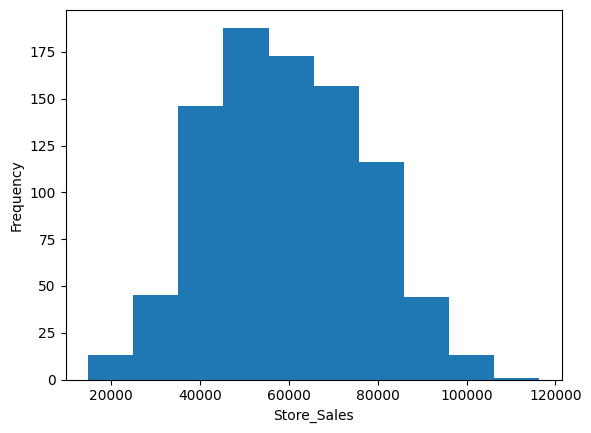

In [29]:
import matplotlib.pyplot as plt
# convert pyspark dataframe to pandas dataframe
pandas_data = data.toPandas()

# create a histogram
plt.hist(pandas_data["Store_Sales"] , bins = 10)
#A histogram shows how frequently values fall within certain ranges.
# Matplotlib divides the values into 10 intervals (bins),
plt.xlabel("Store_Sales")
plt.ylabel("Frequency")
plt.show()

9. Writing Data

Pyspark allows  us to write data back to diffrent formats. Here's an example of how to write a pyspark DataFrame to a parquet file:

In [30]:
# write dataframe to parquet file
data.write.parquet("output.parquet")